# Dados


In [55]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import add_dummy_feature
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [56]:
np.random.seed(42)

m = 1000
X = np.random.rand(m,1)
y = 0.85 * X + 2 + np.random.rand(m,1)

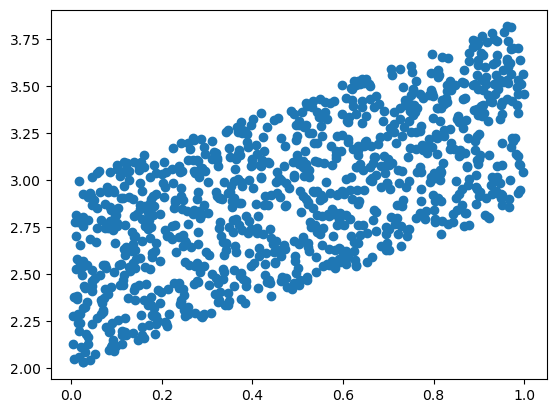

In [57]:
plt.scatter(X, y)
plt.show()

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [59]:
X_test = add_dummy_feature(X_test)
X_train = add_dummy_feature(X_train)
X_plot = add_dummy_feature(X)

A célula acima faz uma cópia do vetor $\mathbf x$, fazendo com que o $\mathbf{X_0}$ seja sempre 1, para que não altere o valor do viés ($\mathbf{\theta_0}$)

# Model

## Using Normal Equation

$$\hat {\boldsymbol{\theta}} = (\mathbf{X^T} \mathbf{X})^{-1} \mathbf{X^T} y$$

In [60]:
class NormalEquation():
    def __init__(self):
        self.intercept_ = None
        self.coef_ = None
        self.theta_ = None
    
    def fit(self, X, y):
        self.theta_ = np.linalg.inv(X.T @ X) @ X.T @ y

        self.intercept_ = self.theta_[0, 0]
        self.coef_ = self.theta_[1:, :].flatten()
        return self
    
    def predict(self, X): 
        return X @ self.theta_

In [61]:
normal_model = NormalEquation()

In [62]:
normal_model.fit(X_train, y_train)

## Gradient Descent

$$\frac{\partial}{\partial \theta_j} = 
\frac2m \sum\limits_{i=1}^m \ (\boldsymbol{\theta^T}\mathbf{x}^{(i)} - y^{(i)})  x_j^{(i)}$$

$$\nabla_{\boldsymbol{\theta}} = 
\begin{pmatrix}
    \frac{\partial}{\partial \theta_0} \\
    \frac{\partial}{\partial \theta_1} \\
    \vdots \\
    \frac{\partial}{\partial \theta_n}
\end{pmatrix} 
= \frac{2}{m} \mathbf{X}^{T} (\mathbf{X} \boldsymbol{\theta} - \mathbf{y})$$

$$\boldsymbol{\theta}^{\text{(next step)}} = \boldsymbol{\theta} - \eta \nabla_{\boldsymbol{\theta}}$$

### Using Batch Gradient 

In [63]:
class BatchGradient():
    def __init__(self):
        self.intercept_ = None
        self.coef_ = None
        self.theta_ = np.random.rand(2, 1)

    def fit(self, X, y, eta=0.1, n_epochs=1000):
        m = len(X)

        for epoch in range(n_epochs):
            gradients = (2 / m) * X.T @ (X @ self.theta_ - y)
            self.theta_ = self.theta_ - eta * gradients

        self.intercept_ = self.theta_[0, 0]
        self.coef_ = self.theta_[1:, :].flatten()
        return self

    def predict(self, X): 
        return X @ self.theta_

In [64]:
batch_model = BatchGradient()

In [65]:
batch_model.fit(X_train, y_train)

### Using Stochastic Gradient

In [66]:
class StochasticGradient():
    def __init__(self, t0=5, t1=50):
        self.intercept_ = None
        self.coef_ = None
        self.theta_ = np.random.rand(2, 1)
        self.t0 = t0
        self.t1 = t1
    
    def __learning_schedule(self, t):
        return self.t0 / (t + self.t1)

    def fit(self, X, y, eta=0.01, n_epochs=50):
        m = len(X)

        for epoch in range(n_epochs):
            for iteration in range(m):
                random_index = np.random.randint(m)

                x_i = X[random_index : random_index + 1]
                y_i = y[random_index : random_index + 1]

                gradients =  2 * x_i.T @ (x_i @ self.theta_ - y_i)
                eta = self.__learning_schedule(epoch * m + iteration)
                self.theta_ = self.theta_ - eta * gradients
        self.intercept_ = self.theta_[0, 0]
        self.coef_ = self.theta_[1:, :].flatten()
        return self

    def predict(self, X): 
        return X @ self.theta_

In [67]:
stochastic_model = StochasticGradient()

In [68]:
stochastic_model.fit(X_train, y_train)

# Comparando com `scikit-learn`

In [69]:
sk_model = LinearRegression()

In [70]:
sk_model.fit(X_train, y_train)

LinearRegression()

In [71]:
print(f'Normal Equation: \n Bias: {normal_model.intercept_} \t Weight: {normal_model.coef_}')
print(f'Batch Gradient: \n Bias: {batch_model.intercept_} \t Weight: {batch_model.coef_}')
print(f'Stochastic Gradient: \n Bias: {stochastic_model.intercept_} \t Weight: {stochastic_model.coef_}')
print(f'Scikit-Learn: \n Bias: {sk_model.intercept_} \t Weight: {sk_model.coef_}')

Normal Equation: 
 Bias: 2.489204964938369 	 Weight: [0.90597912]
Batch Gradient: 
 Bias: 2.489204714579681 	 Weight: [0.90597959]
Stochastic Gradient: 
 Bias: 2.4956794237725375 	 Weight: [0.90561908]
Scikit-Learn: 
 Bias: [2.48920496] 	 Weight: [[0.         0.90597912]]


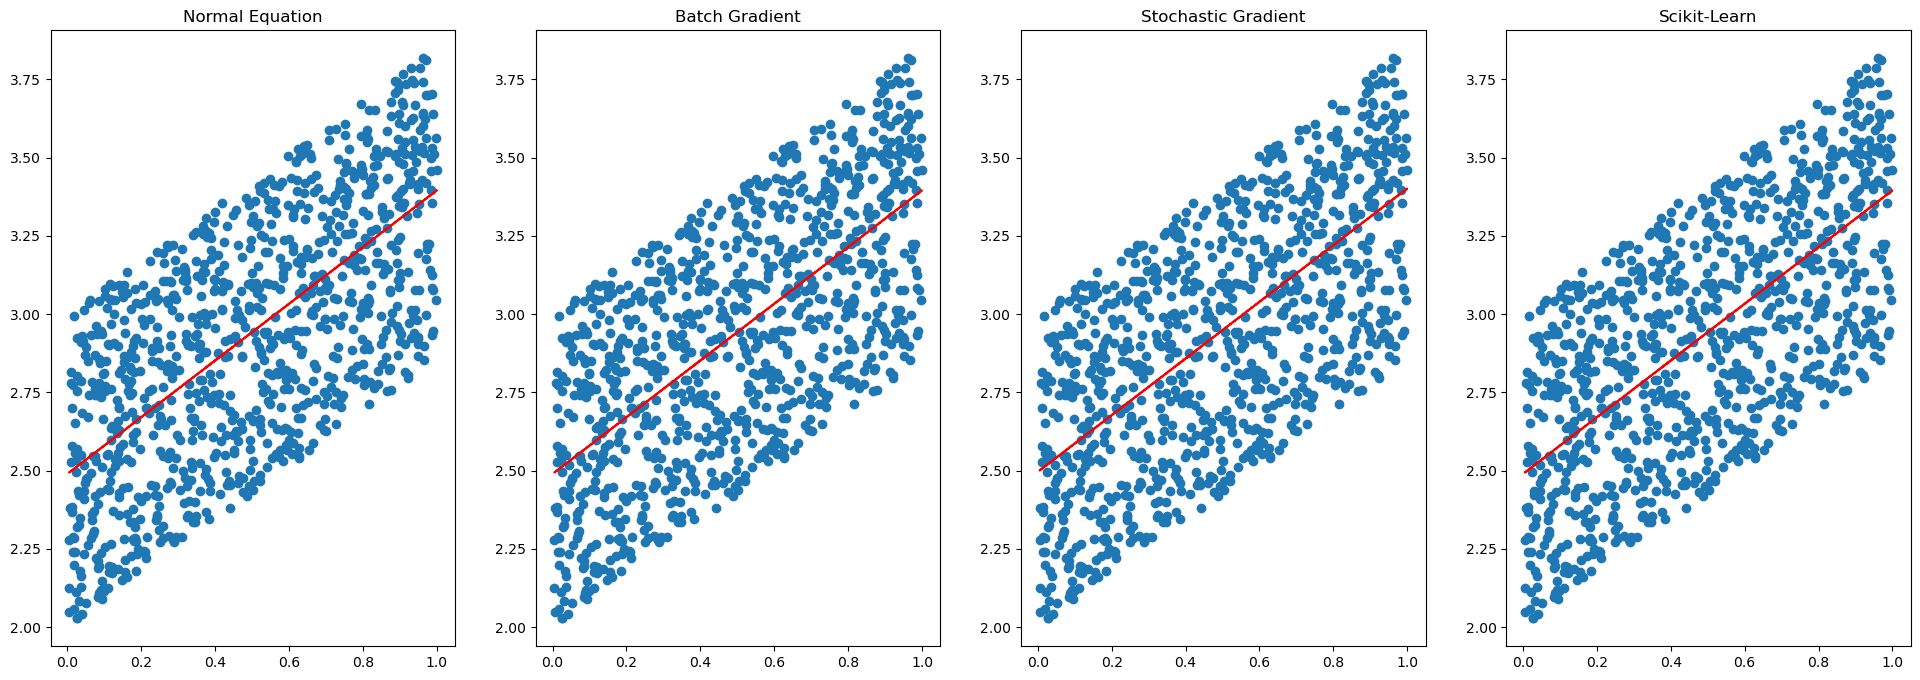

In [72]:
fig, axes = plt.subplots(1, 4, figsize=(24,8))

axes[0].plot(X, normal_model.predict(X_plot), 'r-')
axes[0].scatter(X, y)
axes[0].set_title('Normal Equation')

axes[1].plot(X, batch_model.predict(X_plot), 'r-')
axes[1].scatter(X, y)
axes[1].set_title('Batch Gradient')

axes[2].plot(X, stochastic_model.predict(X_plot), 'r-')
axes[2].scatter(X, y)
axes[2].set_title('Stochastic Gradient')

axes[3].plot(X, sk_model.predict(X_plot), 'r-')
axes[3].scatter(X, y)
axes[3].set_title('Scikit-Learn')

plt.show()